In [ ]:
%load_ext autoreload
%autoreload 2

### 1. 모듈 임포트

In [1]:
import torch
import numpy as np
# 1. 모듈 임포트
from modules.config import config
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features, visualize_feature_grid

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# ==========================================
# Setup: Config & 디바이스 초기화
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚡ 디바이스 초기화: {device}")

⚙️ Config 설정: Domain Size=2.0, Resolution=64
⚡ 디바이스 초기화: cuda


gpu 가속 코드(AMD ver.)

In [ ]:
import torch_directml
device = torch_directml.device() 
print(f"현재 디바이스: {device}")

## 2. 데이터셋 생성

### 2.1 데이터 셋 sdf 생성 및 Poisson Disk 샘플링

In [2]:
# 🚨 [추가] 섞기(Shuffle)의 재현성을 위한 시드 고정!
# 이 줄을 추가하면 언제, 어느 컴퓨터에서 돌려도 똑같은 순서로 섞입니다.
np.random.seed(42)

In [5]:
len(ppc_list)

48

In [ ]:
import os
import glob

OUTPUT_DIR = "dataset2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Clean up old single shape files to avoid confusion
# old_files = glob.glob(os.path.join(OUTPUT_DIR, "*.npy"))
# for f in old_files:
#     os.remove(f)
#     print(f"Removed old dataset file: {f}")

DATASET_SIZE = 100
ppc_list = [1, 2, 3, 4] * (DATASET_SIZE // 4)
np.random.shuffle(ppc_list)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = SDFGenerator(config)
feature_constructor = FeatureConstruction(dx=config.dx, device=device)

START_INDEX = 0  # 🚨 여기서부터 시작합니다.
print(f"\n🚀 Generating {DATASET_SIZE} training samples (SDF + m_c grids)...")

for i in range(START_INDEX, DATASET_SIZE):
    # 🚨 [수정] 무작위로 섞인 리스트에서 이번 차례의 ppc 값을 꺼내옵니다.
    current_ppc = ppc_list[i]
    
    print(f"\n[{i+1}/{DATASET_SIZE}] Generating shape... (Target PPC: {current_ppc})")
    
    # 1. Generate SDF
    random_shape = generator.create_random_shape(seed=42 + i)
    sdf_grid = generator.to_grid(random_shape)
    
    # 2. Sample Particles
    print(f"  Sampling particles with PPC={current_ppc}...")
    particles = sample_particles_poisson(sdf_grid, config, target_ppc=current_ppc)
    
    # 3. Calculate m_c feature grid
    print("  Calculating m_c features...")
    particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)
    grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
    mc_grid = m_c.reshape(grid_shape).cpu().numpy()
    
    # 4. Save
    sdf_filename = os.path.join(OUTPUT_DIR, f"sdf_grid_{i:03d}.npy")
    mc_filename = os.path.join(OUTPUT_DIR, f"mc_grid_{i:03d}.npy")
    
    np.save(sdf_filename, sdf_grid)
    np.save(mc_filename, mc_grid)
    print(f"  Saved: {sdf_filename}, {mc_filename}")

print("\n✅ Dataset generation complete! Files are ready in the 'dataset' folder.")



🚀 Generating 50 training samples (SDF + m_c grids)...

[10/50] Generating shape... (Target PPC: 4)
  Sampling particles with PPC=4...
   -> 도형 부피 비율: 16.4%
   -> 타겟 PPC: 4 / 고정된 반지름(r): 0.0170
   -> 최종 생성된 파티클 수: 155807개
  Calculating m_c features...
  Saved: dataset3\sdf_grid_009.npy, dataset3\mc_grid_009.npy

[11/50] Generating shape... (Target PPC: 1)
  Sampling particles with PPC=1...
   -> 도형 부피 비율: 15.8%
   -> 타겟 PPC: 1 / 고정된 반지름(r): 0.0270
   -> 최종 생성된 파티클 수: 37790개
  Calculating m_c features...
  Saved: dataset3\sdf_grid_010.npy, dataset3\mc_grid_010.npy

[12/50] Generating shape... (Target PPC: 2)
  Sampling particles with PPC=2...
   -> 도형 부피 비율: 9.1%
   -> 타겟 PPC: 2 / 고정된 반지름(r): 0.0214
   -> 최종 생성된 파티클 수: 43041개
  Calculating m_c features...
  Saved: dataset3\sdf_grid_011.npy, dataset3\mc_grid_011.npy

[13/50] Generating shape... (Target PPC: 2)
  Sampling particles with PPC=2...
   -> 도형 부피 비율: 4.2%
   -> 타겟 PPC: 2 / 고정된 반지름(r): 0.0214
   -> 최종 생성된 파티클 수: 19710개
  Calcula

IndexError: list index out of range

📥 SDF 데이터 로드: dataset3/sdf_grid_002.npy (Shape: (64, 64, 64))
📥 m_c 데이터 로드: dataset3/mc_grid_002.npy (Shape: (64, 64, 64))

[1] 정답(Target) SDF 형상 시각화


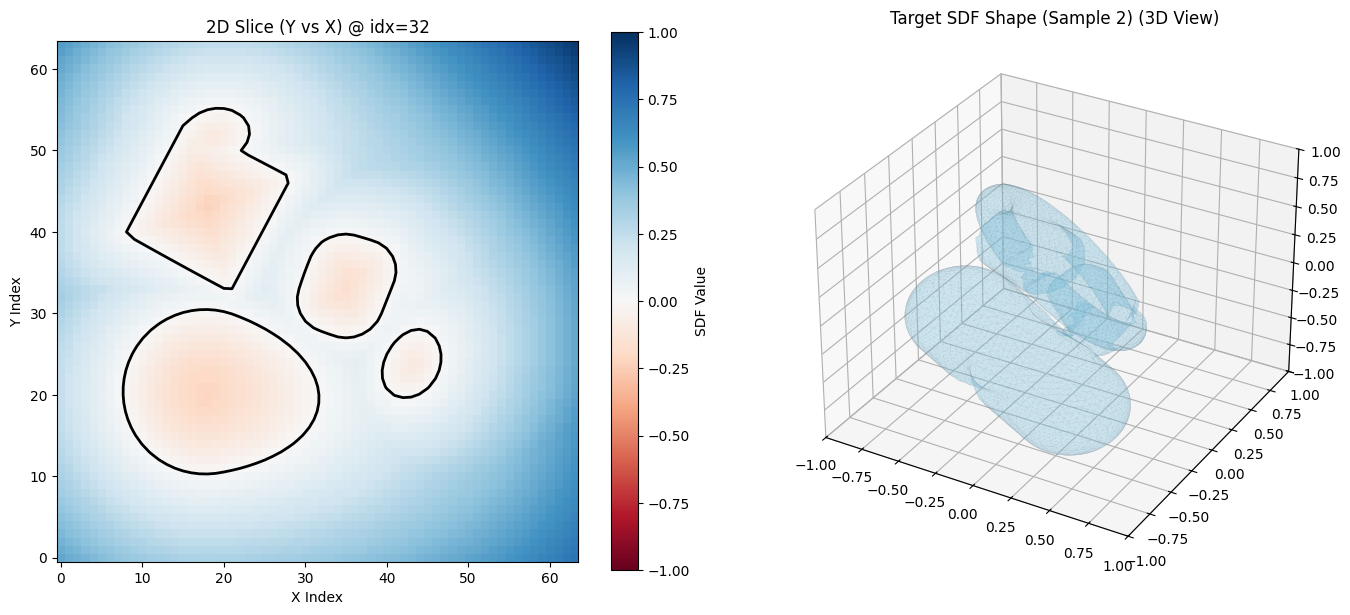

In [6]:
import numpy as np
import torch
from modules.config import config
from modules.visualizer import visualize_simulation, visualize_feature_grid,visualize_particles_and_features

# 1. 확인할 데이터 인덱스 설정 (0 ~ 4)
sample_idx = 2
sdf_file = f"dataset3/sdf_grid_{sample_idx:03d}.npy"
mc_file = f"dataset3/mc_grid_{sample_idx:03d}.npy"

# 2. 데이터 로드 완료
sdf_grid = np.load(sdf_file)
mc_grid = np.load(mc_file)
print(f"📥 SDF 데이터 로드: {sdf_file} (Shape: {sdf_grid.shape})")
print(f"📥 m_c 데이터 로드: {mc_file} (Shape: {mc_grid.shape})")

# 3. [시각화 1] Target SDF (원본 3D 지오메트리 형태)
print("\n[1] 정답(Target) SDF 형상 시각화")
visualize_simulation(
    sdf_grid=sdf_grid, 
    domain_size=config.domain_size, 
    title=f"Target SDF Shape (Sample {sample_idx})"
)

✅ 복구된 grid_nodes 형태: torch.Size([262144, 3])

[2] 입력(Input) m_c 특징 공간 시각화


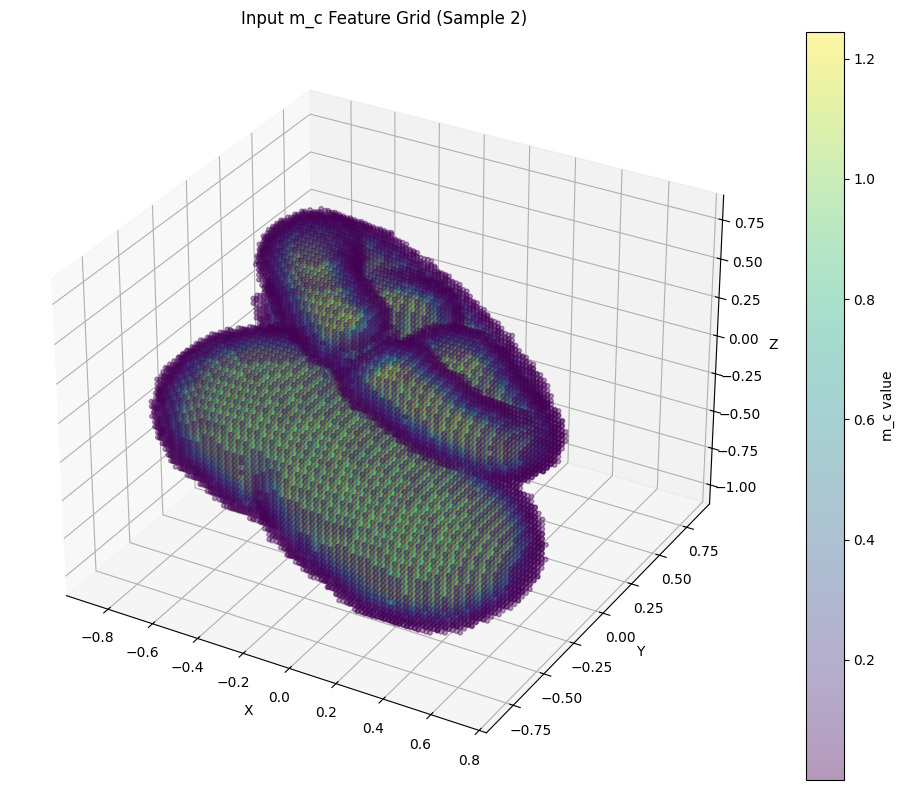

In [7]:
# 1. 기존 Config 설정값 기준
domain_size = 2.0
resolution = 64

min_bound = -domain_size / 2.0  # -1.0
max_bound = domain_size / 2.0   # 1.0

# 2. X, Y, Z 축 각각에 대해 -1.0 부터 1.0 까지 64등분한 좌표점 생성
axis_coords = torch.linspace(min_bound, max_bound, resolution)

# 3. 3차원 공간(Meshgrid)으로 확장하여 (64, 64, 64, 3) 형태의 텐서 생성
X, Y, Z = torch.meshgrid(axis_coords, axis_coords, axis_coords, indexing='ij')

# 4. 좌표들을 하나로 묶고 (262144, 3) 형태로 평탄화(Flatten)
grid_nodes = torch.stack([X, Y, Z], dim=-1).reshape(-1, 3)

print(f"✅ 복구된 grid_nodes 형태: {grid_nodes.shape}")

# 4. [시각화 2] Input 3D CNN Features (파티클로부터 밀도 단위로 추출된 m_c 값)
print("\n[2] 입력(Input) m_c 특징 공간 시각화")

fig2 = visualize_feature_grid(
    m_c_grid=mc_grid,         # 앞서 파이프라인에서 나온 mc_grid 텐서 그대로 삽입
    grid_nodes=grid_nodes,    # 앞서 파이프라인에서 나온 grid_nodes 텐서 그대로 삽입
    title=f"Input m_c Feature Grid (Sample {sample_idx})"
)

## 3. sdf 계산 -CNN 학습

### 3.1 전처리 단계: 그리드 특징값(m_c) 계산

### 3.2 m_c 값 시각화

In [ ]:
import torch
import numpy as np
import os
# 1. 모듈 임포트
from modules.config import config
from modules.sdf_generator import SDFGenerator
from modules.particle_sampler import sample_particles_poisson
from modules.sdf_network import FeatureConstruction
from modules.visualizer import visualize_simulation, visualize_particles_and_features

# ==========================================
# Setup: Config & 디바이스 초기화
# ==========================================
print(f"⚙️ Config 설정: Domain Size={config.domain_size}, Resolution={config.resolution}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# Phase 1: SDF 도형 생성 및 래스터라이징
# ==========================================
print("\n[Phase 1] 🎲 랜덤 SDF 도형 생성 중...")
# 새로 만든 OOP 클래스를 사용합니다.
generator = SDFGenerator(config)

random_sdf = generator.create_sample_shape() 
sdf_grid = generator.to_grid(random_sdf)

print(f"✅ SDF Grid 생성 완료: Shape={sdf_grid.shape}")

# ==========================================
# Phase 2: Poisson Disk 샘플링
# ==========================================
print("\n[Phase 2] 🎯 파티클 샘플링 중...")
# config 객체를 두 번째 인자로 넘겨받도록 변경된 부분을 반영합니다.
particles = sample_particles_poisson(sdf_grid, config)

print(f"✅ 파티클 샘플링 완료: {len(particles)}개 생성됨 (목표: {config.num_particles}개)")

# ==========================================
# Phase 3: 특징 인코딩 (Feature Construction)
# ==========================================
print("\n[Phase 3] 🧠 모델 입력용 특징(m_c) 추출 중...")
# 함수형 형태를 유지한 원본 FeatureConstruction을 사용하되, dx는 config 참조
feature_constructor = FeatureConstruction(dx=config.dx, device=device)

particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)

# 파티클 위치 기반으로 동적 그리드 변환 
grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
m_c_grid = m_c.reshape(grid_shape).cpu().numpy()

print(f"✅ 기하학적 특징 추출 완료")
print(f"   - Grid Shape: {grid_shape}")
print(f"   - m_c 통계: Min={m_c.min():.4f}, Max={m_c.max():.4f}")

# ==========================================
# Phase 4: 데이터 저장 (.npy)
# ==========================================
print("\n[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...")

# 출력 폴더 생성 (선택 사항, 깔끔한 관리를 위해)
save_dir = "./"
os.makedirs(save_dir, exist_ok=True)

# 텐서로 남아있는 grid_nodes를 numpy로 변환
grid_nodes_np = grid_nodes.cpu().numpy() if isinstance(grid_nodes, torch.Tensor) else grid_nodes

# 각각 .npy 파일로 저장
np.save(os.path.join(save_dir, "sdf_grid_64.npy"), sdf_grid)
np.save(os.path.join(save_dir, "particles_64.npy"), particles)
np.save(os.path.join(save_dir, "mc_grid_64.npy"), m_c_grid)
# np.save(os.path.join(save_dir, "grid_nodes_64.npy"), grid_nodes_np)

print(f"✅ 모든 데이터 저장 완료! (저장 위치: ./{save_dir}/)")



⚙️ Config 설정: Domain Size=2.0, Resolution=64

[Phase 1] 🎲 랜덤 SDF 도형 생성 중...
✅ SDF Grid 생성 완료: Shape=(64, 64, 64)

[Phase 2] 🎯 파티클 샘플링 중...
   -> 도형 부피 비율: 16.6%
   -> 타겟 PPC: 3.0 / 고정된 반지름(r): 0.0187
   -> 최종 생성된 파티클 수: 118564개
✅ 파티클 샘플링 완료: 118564개 생성됨 (목표: 40000개)

[Phase 3] 🧠 모델 입력용 특징(m_c) 추출 중...
✅ 기하학적 특징 추출 완료
   - Grid Shape: torch.Size([64, 64, 64])
   - m_c 통계: Min=0.0000, Max=1.2245

[Phase 4] 💾 생성된 데이터를 .npy 형식으로 저장 중...
✅ 모든 데이터 저장 완료! (저장 위치: ./saved_data/)


In [ ]:

# ==========================================
# Phase 5: 시각화 모듈
# ==========================================
print("\n[Phase 4] 📊 프로세스 검증용 데이터 시각화")

# 4-1. 전반적인 형상 + 파티클 위치 뷰어
# visualize_simulation(
#     sdf_grid=sdf_grid, 
#     particles=particles, 
#     domain_size=config.domain_size, 
#     title="SDF Model & Generated Particles"
# )

# 4-2. 파티클 분포와 네트워크의 m_c 추출 결과 뷰어
visualize_particles_and_features(
    particles=particles_tensor.cpu(),
    grid_nodes=grid_nodes.cpu(),
    m_c_grid=m_c_grid,
    title="Network Feature Distribution (m_c)"
)

=== 현재 디렉토리의 sdf_grid_64.npy 시각화 및 파티클 샘플링 ===
✅ 데이터 로드 성공: sdf_grid_64.npy (Shape: (64, 64, 64))

[파티클 샘플링 중...]
   -> 도형 부피 비율: 2.5%
   -> 타겟 PPC: 3.0 / 고정된 반지름(r): 0.0187
   -> 최종 생성된 파티클 수: 17454개
✅ 추출된 파티클 갯수: 17454

[DirectML 가속으로 m_c 특징값 계산 중...]
✅ m_c 그리드 저장 완료: mc_grid_64.npy (Shape: (64, 64, 64))

[m_c 특징 공간 시각화]


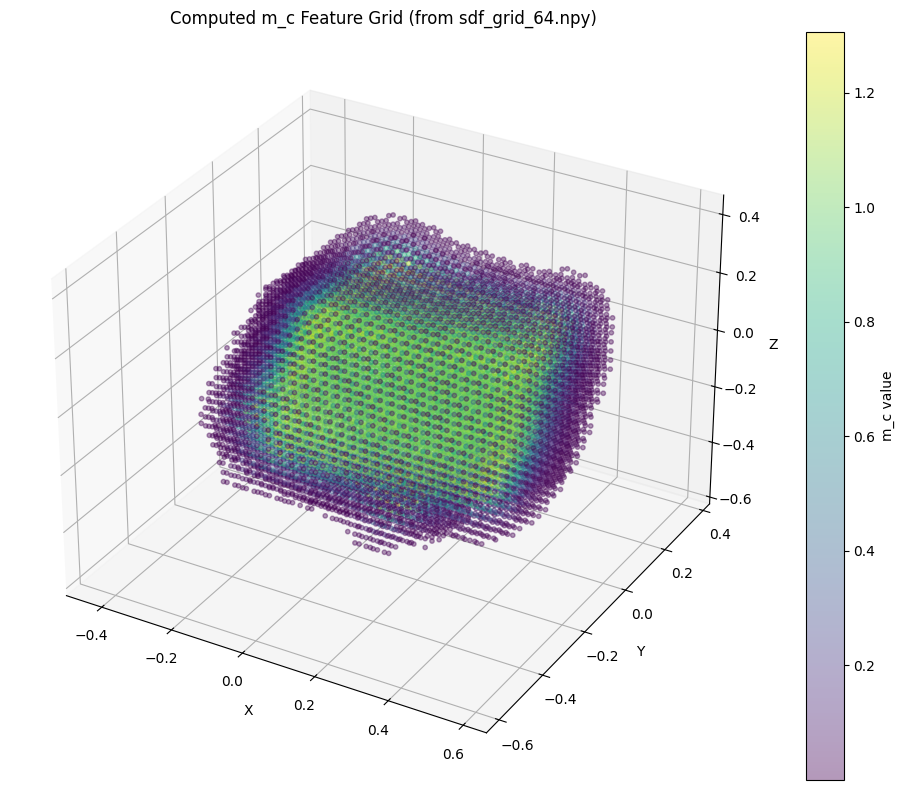

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from modules.config import config
from modules.particle_sampler import sample_particles_poisson
from modules.visualizer import visualize_simulation

print("=== 현재 디렉토리의 sdf_grid_64.npy 시각화 및 파티클 샘플링 ===")

# 1. 원본 SDF 데이터 불러오기
file_path = "sdf_grid_64.npy"
try:
    sdf_grid = np.load(file_path)
    print(f"✅ 데이터 로드 성공: {file_path} (Shape: {sdf_grid.shape})")
except FileNotFoundError:
    print(f"❌ 파일을 찾을 수 없습니다: {file_path}")
    sdf_grid = None
    
if sdf_grid is not None:
    # 2. 파티클 샘플링
    print("\n[파티클 샘플링 중...]")
    particles = sample_particles_poisson(sdf_grid, config)
    print(f"✅ 추출된 파티클 갯수: {len(particles)}")
    # 3. 파티클 위치 기반으로 동적 그리드 변환 및 m_c 계산
    print("\n[DirectML 가속으로 m_c 특징값 계산 중...]")
    feature_constructor = FeatureConstruction(dx=config.dx, device=device)
    particles_tensor = torch.tensor(particles, dtype=torch.float32, device=device)
    
    # 🌟 기존에 구현되어 있는 통합 함수 호출!
    grid_nodes, m_c, grid_shape = feature_constructor(particles_tensor)
    
    # 3D 텐서(64x64x64)로 복원 후 numpy 배열로 변환
    mc_grid = m_c.reshape(grid_shape).cpu().numpy()
    
    # 4. 결과 저장 (mc_grid_64.npy)
    save_path = "mc_grid_64.npy"
    np.save(save_path, mc_grid)
    print(f"✅ m_c 그리드 저장 완료: {save_path} (Shape: {mc_grid.shape})")
    # 5. m_c 3D 특징 맵 시각화
    print("\n[m_c 특징 공간 시각화]")
    fig = visualize_feature_grid(
        m_c_grid=m_c,             # flatten된 1D 텐서 그대로 투입
        grid_nodes=grid_nodes,    # 짝이 완벽하게 맞는 3D 좌표 노드
        title="Computed m_c Feature Grid (from sdf_grid_64.npy)"
    )
    plt.show()

In [25]:
# 1. 확인할 데이터 인덱스 설정 (0 ~ 4)
sdf_file = f"sdf_grid_64.npy"
mc_file = f"mc_grid_64.npy"

# 2. 데이터 로드 완료
sdf_grid = np.load(sdf_file)
mc_grid = np.load(mc_file)
print(f"📥 m_c 데이터 로드: {mc_file} (Shape: {mc_grid.shape})")

fig2 = visualize_feature_grid(
    m_c_grid=mc_grid,         # 앞서 파이프라인에서 나온 mc_grid 텐서 그대로 삽입
    grid_nodes=grid_nodes,    # 앞서 파이프라인에서 나온 grid_nodes 텐서 그대로 삽입
    title=f"Input m_c Feature Grid"
)

FileNotFoundError: [Errno 2] No such file or directory: 'sdf_grid_64.npy'

### 3.3 3D CNN 네트워크를 통한 SDF 값 추론

### 3.4 학습

디바이스/데이터로더 설정 셀

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader

# 모듈 임포트는 유저님 환경에 맞게 유지
from modules.sdf_network import SDFNetwork
from modules.dataset import create_dataloader

# ==========================================
# 🚨 1. DirectML 개입 원천 차단 및 순수 CPU 강제 고정
# ==========================================
# device = torch.device('cpu')
print(f"🔒 현재 강제 고정된 디바이스: {device}")

# 2. 데이터로더 생성 (배치 사이즈는 메모리에 맞게 조절)
print("데이터를 불러옵니다...")
train_loader = create_dataloader(data_dir="dataset3", batch_size=256, in_memory=True)

# 3. 모델 및 옵티마이저 생성 (모델을 강제로 CPU로!)
model = SDFNetwork().to(device)
model.float() # 강제 float32 포맷팅
model.train()

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

🔒 현재 강제 고정된 디바이스: cuda
데이터를 불러옵니다...
💾 데이터를 메모리에 캐싱 중입니다...
✅ 캐싱 완료.


훈련 반복문 셀

In [6]:
import time
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

num_epochs = 10
train_losses = []

start_time = time.time()

# 🚨 [추가] 전체 데이터의 10%만 보고 다음 에폭으로 넘어가도록 설정
max_batches_per_epoch = len(train_loader) // 10 

for epoch in range(num_epochs):
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1:02d}/{num_epochs:02d}]")
    
    for batch_idx, (feature_patch, sdf_target) in enumerate(progress_bar):
        
        # 🚨 [추가] 지정된 배치 수(10%)에 도달하면 이번 에폭은 조기 종료!
        if batch_idx >= max_batches_per_epoch:
            break
            
        feature_patch = feature_patch.to(device, dtype=torch.float32)
        sdf_target = sdf_target.to(device, dtype=torch.float32)
        
        if feature_patch.dim() == 4:
            feature_patch = feature_patch.unsqueeze(1)
            
        optimizer.zero_grad()
        pred_sdf = model(feature_patch)
        loss = criterion(pred_sdf.squeeze(-1), sdf_target.squeeze(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * feature_patch.size(0)
        
        if batch_idx % 10 == 0:
            progress_bar.set_postfix({'loss': f"{loss.item():.5f}"})
            
    # 평균 Loss 계산 시 분모도 우리가 실제로 본 데이터 개수로 맞춰줍니다.
    actual_samples_seen = max_batches_per_epoch * train_loader.batch_size
    avg_loss = running_loss / actual_samples_seen
    train_losses.append(avg_loss)
    print(f"✅ Epoch {epoch+1} 완료! 최종 평균 Loss: {avg_loss:.6f}\n")

elapsed_time = time.time() - start_time
print(f"✅ 학습 완료! (총 소요 시간: {elapsed_time:.1f}초)")

Epoch [01/10]:  10%|▉         | 4915/49152 [01:14<11:10, 65.95it/s, loss=0.02620]


✅ Epoch 1 완료! 최종 평균 Loss: 0.030472



Epoch [02/10]:  10%|▉         | 4915/49152 [01:13<11:03, 66.68it/s, loss=0.02793]


✅ Epoch 2 완료! 최종 평균 Loss: 0.029217



Epoch [03/10]:  10%|▉         | 4915/49152 [01:13<11:05, 66.45it/s, loss=0.02887]


...

✅ Epoch 8 완료! 최종 평균 Loss: 0.027228



Epoch [09/10]:  10%|▉         | 4915/49152 [01:13<11:03, 66.67it/s, loss=0.02445]


✅ Epoch 9 완료! 최종 평균 Loss: 0.026951



Epoch [10/10]:  10%|▉         | 4915/49152 [01:13<11:04, 66.57it/s, loss=0.02522]

✅ Epoch 10 완료! 최종 평균 Loss: 0.026699

✅ 학습 완료! (총 소요 시간: 739.3초)


In [ ]:
import time
import torch
import matplotlib.pyplot as plt
# 🚨 [추가] 진행률 바를 위한 라이브러리 임포트
from tqdm import tqdm 

# ==========================================
# 🚨 4. 본격 학습 루프 (진행률 바 적용 버전)
# ==========================================
num_epochs = 15
train_losses = []

print("=== [Step 3] 100% 순수 CPU 3D CNN 학습 시작 ===")
start_time = time.time()

for epoch in range(num_epochs):
    running_loss = 0.0
    
    # 🚨 [핵심 수정] train_loader를 tqdm으로 감싸줍니다.
    # 이렇게 하면 아래에 로딩 바가 생기면서 몇 % 진행됐는지 실시간으로 보여줍니다.
    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1:02d}/{num_epochs:02d}]")
    
    for batch_idx, (feature_patch, sdf_target) in enumerate(progress_bar):
        # 데이터 이동
        feature_patch = feature_patch.to(device, dtype=torch.float32)
        sdf_target = sdf_target.to(device, dtype=torch.float32)
        
        # 5차원 안전장치
        if feature_patch.dim() == 4:
            feature_patch = feature_patch.unsqueeze(1)
            
        optimizer.zero_grad()
        
        # 순전파 -> 손실 계산 -> 역전파
        pred_sdf = model(feature_patch)
        loss = criterion(pred_sdf.squeeze(-1), sdf_target.squeeze(-1))
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * feature_patch.size(0)
        
        # 🚨 [추가] 진행률 바 옆에 현재 학습 중인 Loss 값을 실시간으로 업데이트!
        if batch_idx % 10 == 0:  # 너무 자주 업데이트하면 느려지므로 10번마다 갱신
            progress_bar.set_postfix({'loss': f"{loss.item():.5f}"})
            
    # 에폭이 완전히 끝난 후 평균 Loss 계산 및 기록
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f"✅ Epoch {epoch+1} 완료! 최종 평균 Loss: {avg_loss:.6f}\n")

elapsed_time = time.time() - start_time
print(f"🎉 모든 학습 완료! (총 소요 시간: {elapsed_time:.1f}초)")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch_directml
from torch.utils.data import DataLoader

from modules.dataset import SDFDataset
from modules.sdf_network import SDFNetwork

print("=== [Step 1 & 2] 디바이스, 데이터셋 및 모델 초기화 ===")

# 1. 🚀 DirectML 가속 디바이스 할당 (AMD GPU 가동!)
device = torch_directml.device()
print(f"🔥 현재 사용 중인 가속 디바이스: {device}")

# 2. 📦 학습 데이터셋(5개 기본 도형) 메모리 로드
print("\n[데이터셋 로드 중...]")
train_dataset = SDFDataset(data_dir="dataset", patch_size=8, in_memory=True)
# 배치 사이즈: 512 (GPU 메모리 상태에 따라 추후 가감 가능)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, drop_last=True)
print(f"✅ 총 {len(train_dataset)} 개의 (8x8x8) 학습 패치 추출 완료!")
print(f"✅ 1 에폭(Epoch)당 미니배치 개수: {len(train_loader)} 번")

# 3. 🧠 3D CNN 모델 인스턴스화
model = SDFNetwork().to(device)

# 4. 📉 손실 함수 및 최적화 알고리즘
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("\n✅ 모델, Loss, Optimizer까지 완벽하게 스탠바이가 완료되었습니다!")


In [ ]:
import matplotlib.pyplot as plt
import time

print("=== [Step 3] 3D CNN (SDFNetwork) 본격 학습 시작 ===")
num_epochs = 15 # 테스트용으로 15번 정도 반복합니다.
train_losses = []

# 모델 훈련 모드 전환 (반드시 float32 캐스팅)
model = model.float()
model.train()

start_time = time.time()
for epoch in range(num_epochs):
    running_loss = 0.0
    
    # 1 에폭 = 전체 데이터셋을 한 번 훑는 과정
    for batch_idx, (feature_patch, sdf_target) in enumerate(train_loader):
        # 1. 데이터를 GPU(AMD DirectML)로 이동하면서 강제로 float32(기본 소수점)로 포맷팅!
        feature_patch = feature_patch.to(device, dtype=torch.float32)
        sdf_target = sdf_target.to(device, dtype=torch.float32)
        
        # 안전장치: 혹시라도 4D로 찌그러졌으면 강제로 1채널 5D로 폄
        if feature_patch.dim() == 4:
            feature_patch = feature_patch.unsqueeze(1)
            
        # 2. 기울기 초기화
        optimizer.zero_grad()
        
        # 3. 순전파 (Forward Pass): 8x8x8 특징값 -> SDF 예측
        pred_sdf = model(feature_patch)
        
        # 4. 손실 계산 (예측값과 정답 타겟 간의 차이)
        loss = criterion(pred_sdf.squeeze(-1), sdf_target.squeeze(-1))
        
        # 5. 역전파 및 가중치 업데이트 (Backpropagation)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * feature_patch.size(0)
        
    # 에폭별 평균 손실 기록
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] 📉 Average Loss: {avg_loss:.6f}")

elapsed_time = time.time() - start_time
print(f"✅ 학습 완료! (총 소요 시간: {elapsed_time:.1f}초)")

print("\n=== [Step 4] Training Loss 시각화 ===")
# Loss가 꾸준히 우하향(우측으로 갈수록 떨어짐)하는지 검증합니다.
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', color='b')
plt.title("3D CNN Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


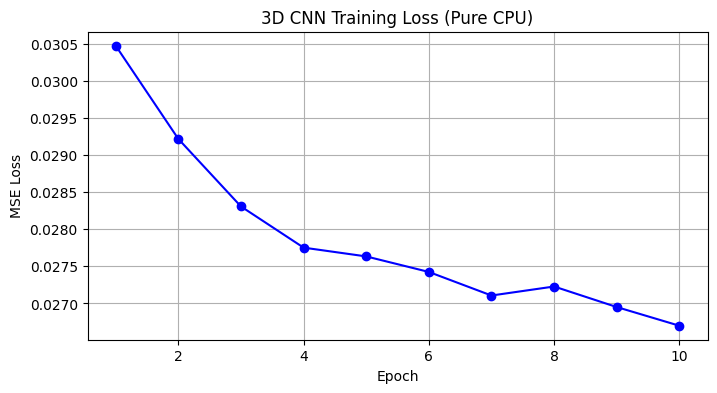

💾 CPU로 학습된 가중치가 안전하게 저장되었습니다!


In [12]:

# ==========================================
# 5. Loss 그래프 시각화
# ==========================================
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', linestyle='-', color='b')
plt.title("3D CNN Training Loss (Pure CPU)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# 6. 소중한 가중치 저장
torch.save(model.state_dict(), "sdf_network_cpu.pth")
print("💾 CPU로 학습된 가중치가 안전하게 저장되었습니다!")

=== [Step 5] 계산된 mc_grid.npy 기반 다이렉트 SDF 추론 ===
✅ 저장된 타겟 SDF & m_c 특징 그리드 로드 완료
   -> 입력 데이터 크기: (64, 64, 64)

[🚀 3D CNN 무지성 스캐닝 가동 중...]

✅ 추론 완료! (소요 시간: 2.19초)

=== [Step 6] 결과물 비교 및 시각화 ===


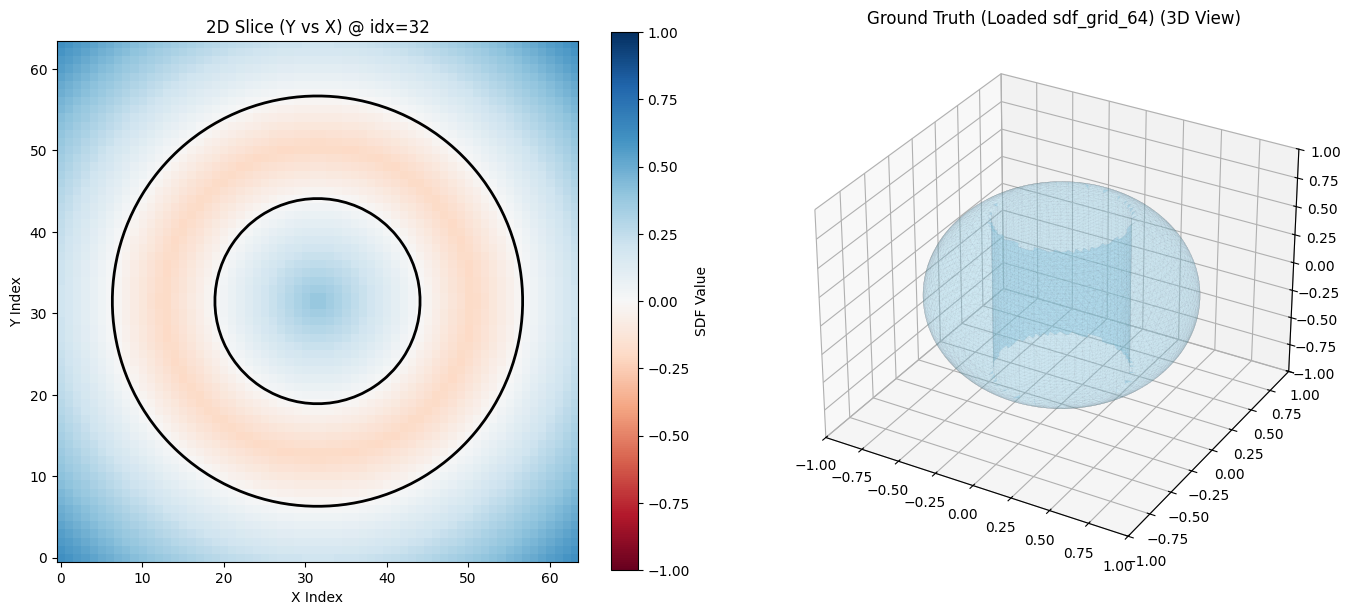

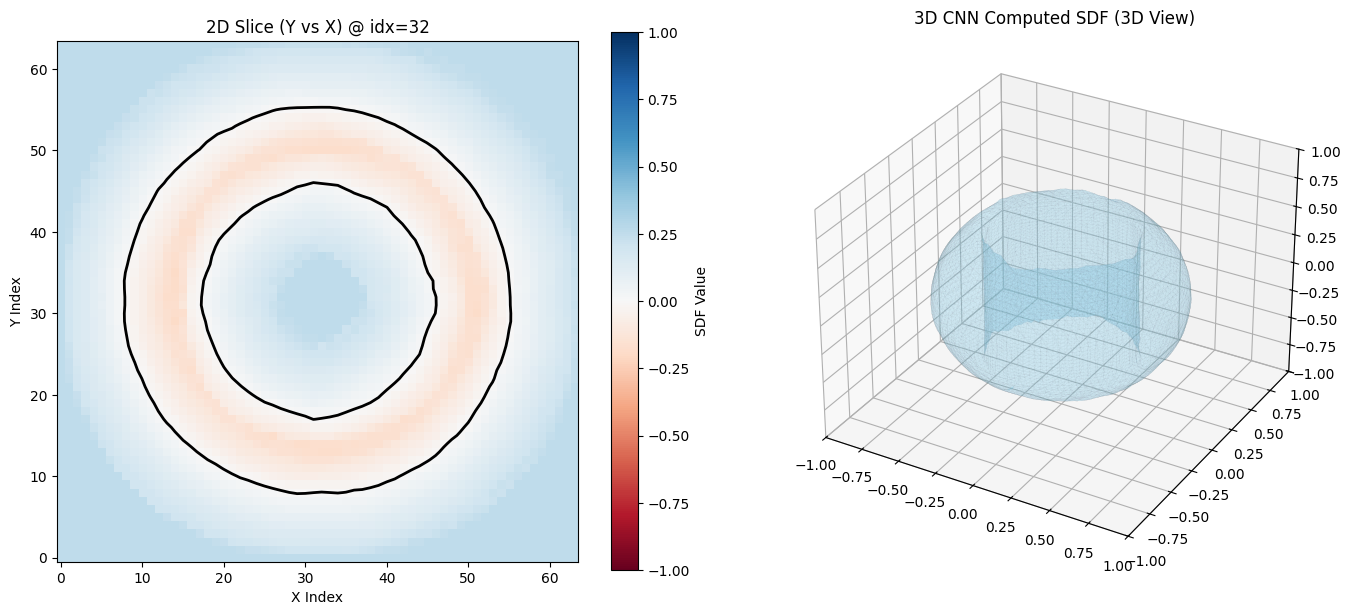

In [26]:
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from modules.sdf_network import SDFReconstruction
from modules.config import config
from modules.visualizer import visualize_simulation

print("=== [Step 5] 계산된 mc_grid.npy 기반 다이렉트 SDF 추론 ===")

# 1. 아까 저장해둔 타겟 & 특징 그리드 로드 (전처리 완전 생략!)
target_sdf = np.load("sdf_grid_64.npy")
m_c_grid_np = np.load("mc_grid_64.npy")

print("✅ 저장된 타겟 SDF & m_c 특징 그리드 로드 완료")
print(f"   -> 입력 데이터 크기: {m_c_grid_np.shape}")

# 2. 모델 평가 세팅
model.eval()
device = next(model.parameters()).device  # 현재 모델이 있는 디바이스(DirectML)
patch_size = 8
batch_size = 2048
res = config.resolution

# 전체 64x64x64 노드의 인덱스(1D -> 3D)를 추적할 리스트
num_nodes = res ** 3
grid_shape = (res, res, res)
sdf_values = torch.zeros(num_nodes, device=device)

# 3. 데이터 준비 (Tensor 변환 및 Padding)
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)
# 중심 노드를 긁어갈 때 테두리를 넘지 않도록 Zero-Padding 부착
pad_size = 4
padded_m_c_grid = F.pad(m_c_grid_tensor, (pad_size, pad_size, pad_size, pad_size, pad_size, pad_size), mode='constant', value=0)

start_time = time.time()
print("\n[🚀 3D CNN 무지성 스캐닝 가동 중...]")

with torch.no_grad():
    for i in range(0, num_nodes, batch_size):
        batch_end = min(i + batch_size, num_nodes)
        batch_patches = []
        
        # 슬라이딩 윈도우 추출
        for idx in range(i, batch_end):
            c_idx = np.unravel_index(idx, grid_shape)
            cx, cy, cz = c_idx
            
            # 패딩이 붙었기 때문에 원본 인덱스(cx, cy, cz)가 곧바로 8x8x8 패치의 시작점이 됨
            patch = padded_m_c_grid[
                cx : cx + patch_size,
                cy : cy + patch_size,
                cz : cz + patch_size
            ]
            batch_patches.append(patch.unsqueeze(0).unsqueeze(0))
            
        # GPU 로라!
        batch_tensor = torch.cat(batch_patches, dim=0).to(device)
        batch_sdf = model(batch_tensor)
        
        sdf_values[i:batch_end] = batch_sdf.squeeze(-1)

print(f"\n✅ 추론 완료! (소요 시간: {time.time() - start_time:.2f}초)")


# ----------------------------------------------------

print("\n=== [Step 6] 결과물 비교 및 시각화 ===")

# [1] 원본 정답 SDF 시각화 (도넛)
visualize_simulation(
    sdf_grid=target_sdf, 
    domain_size=config.domain_size, 
    title=f"Ground Truth (Loaded sdf_grid_64)"
)

# [2] CNN 예측결과 시각화
pred_sdf_grid = sdf_values.cpu().numpy().reshape(grid_shape)

# 예측된 SDF 그리드 렌더링
visualize_simulation(
    sdf_grid=pred_sdf_grid,
    domain_size=config.domain_size, 
    title=f"3D CNN Computed SDF"
)


=== [Step 5] 계산된 mc_grid.npy 기반 다이렉트 SDF 추론 ===
✅ 저장된 타겟 SDF & m_c 특징 그리드 로드 완료
   -> 입력 데이터 크기: (64, 64, 64)

[🚀 3D CNN 무지성 스캐닝 가동 중...]

✅ 추론 완료! (소요 시간: 2.36초)

=== [Step 6] 결과물 비교 및 시각화 ===


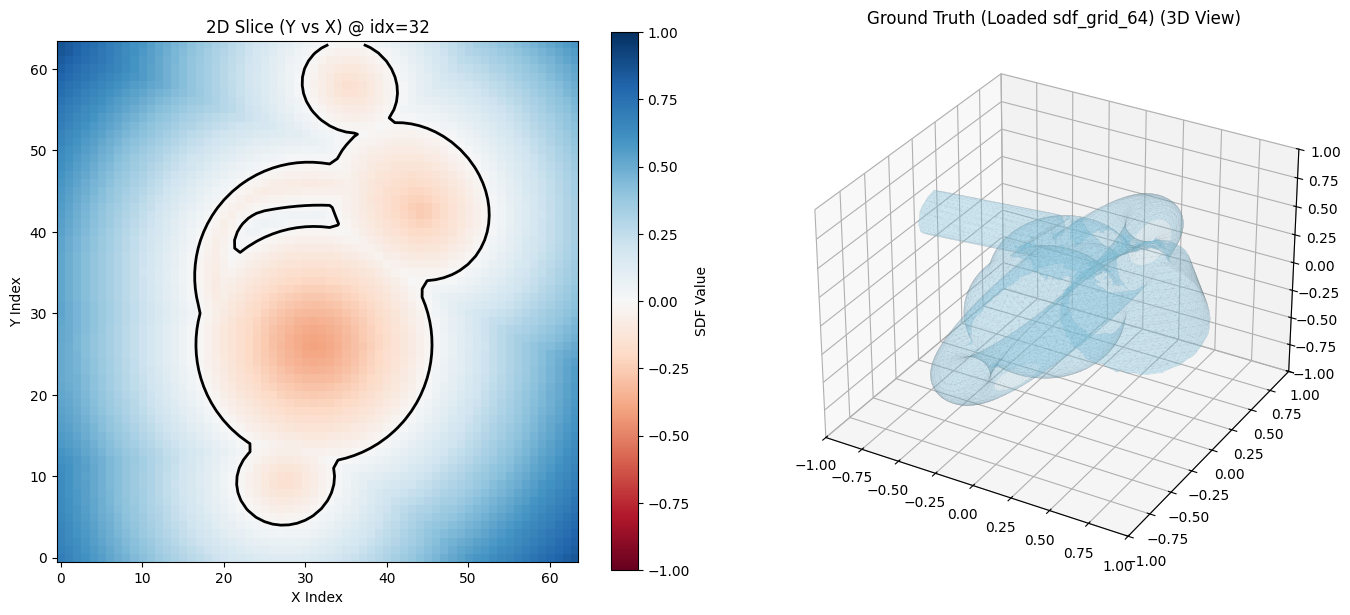

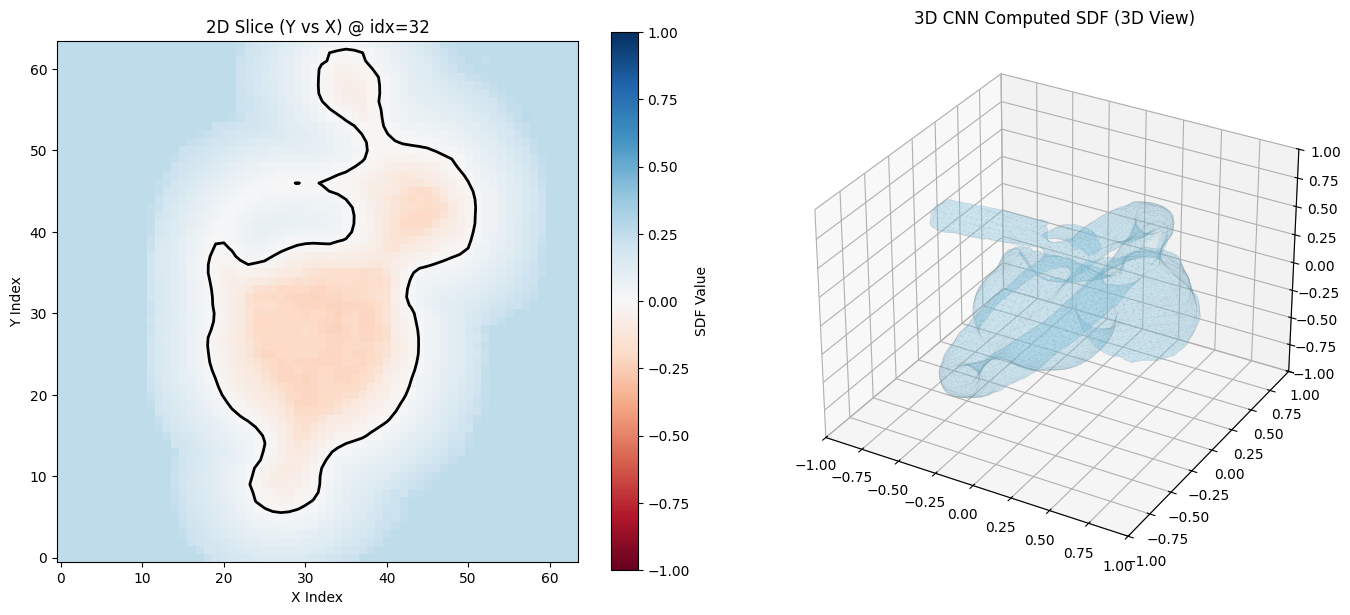

In [15]:
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from modules.sdf_network import SDFReconstruction
from modules.config import config
from modules.visualizer import visualize_simulation

print("=== [Step 5] 계산된 mc_grid.npy 기반 다이렉트 SDF 추론 ===")

# 1. 아까 저장해둔 타겟 & 특징 그리드 로드 (전처리 완전 생략!)
target_sdf = np.load("dataset3/sdf_grid_010.npy")
m_c_grid_np = np.load("dataset3/mc_grid_010.npy")

print("✅ 저장된 타겟 SDF & m_c 특징 그리드 로드 완료")
print(f"   -> 입력 데이터 크기: {m_c_grid_np.shape}")

# 2. 모델 평가 세팅
model.eval()
device = next(model.parameters()).device  # 현재 모델이 있는 디바이스(DirectML)
patch_size = 8
batch_size = 2048
res = config.resolution

# 전체 64x64x64 노드의 인덱스(1D -> 3D)를 추적할 리스트
num_nodes = res ** 3
grid_shape = (res, res, res)
sdf_values = torch.zeros(num_nodes, device=device)

# 3. 데이터 준비 (Tensor 변환 및 Padding)
m_c_grid_tensor = torch.tensor(m_c_grid_np, dtype=torch.float32)
# 중심 노드를 긁어갈 때 테두리를 넘지 않도록 Zero-Padding 부착
pad_size = 4
padded_m_c_grid = F.pad(m_c_grid_tensor, (pad_size, pad_size, pad_size, pad_size, pad_size, pad_size), mode='constant', value=0)

start_time = time.time()
print("\n[🚀 3D CNN 무지성 스캐닝 가동 중...]")

with torch.no_grad():
    for i in range(0, num_nodes, batch_size):
        batch_end = min(i + batch_size, num_nodes)
        batch_patches = []
        
        # 슬라이딩 윈도우 추출
        for idx in range(i, batch_end):
            c_idx = np.unravel_index(idx, grid_shape)
            cx, cy, cz = c_idx
            
            # 패딩이 붙었기 때문에 원본 인덱스(cx, cy, cz)가 곧바로 8x8x8 패치의 시작점이 됨
            patch = padded_m_c_grid[
                cx : cx + patch_size,
                cy : cy + patch_size,
                cz : cz + patch_size
            ]
            batch_patches.append(patch.unsqueeze(0).unsqueeze(0))
            
        # GPU 로라!
        batch_tensor = torch.cat(batch_patches, dim=0).to(device)
        batch_sdf = model(batch_tensor)
        
        sdf_values[i:batch_end] = batch_sdf.squeeze(-1)

print(f"\n✅ 추론 완료! (소요 시간: {time.time() - start_time:.2f}초)")


# ----------------------------------------------------

print("\n=== [Step 6] 결과물 비교 및 시각화 ===")

# [1] 원본 정답 SDF 시각화 (도넛)
visualize_simulation(
    sdf_grid=target_sdf, 
    domain_size=config.domain_size, 
    title=f"Ground Truth (Loaded sdf_grid_64)"
)

# [2] CNN 예측결과 시각화
pred_sdf_grid = sdf_values.cpu().numpy().reshape(grid_shape)

# 예측된 SDF 그리드 렌더링
visualize_simulation(
    sdf_grid=pred_sdf_grid,
    domain_size=config.domain_size, 
    title=f"3D CNN Computed SDF"
)


## 4. SDF 값 시각화 (최종 결과)

4.2 obj로 저장(mc 알고리즘)

In [ ]:
from modules.visualizer import save_mesh_as_obj # 시각화용
save_mesh_as_obj(sdf_grid, filename="train_shape_64.obj")
save_mesh_as_obj(pred_sdf_grid, filename="test_shape_64.obj")

✅ 메쉬 저장 완료: test_shape_64.obj (Vertices: 12616)


npy 파일 이용한 sdf 시각화

In [ ]:
from modules.visualizer import visualize_npy
# 2. 데이터 시각화 (Phase 2)
print("\n--- Phase 2: 시각화 및 저장 ---")

# SDF 파일 확인
visualize_npy("sdf_grid_64.npy")

# 파티클 파일 확인
visualize_npy("particles.npy")


변수(객체) 이용한 시각화(런타임에 있는 메모리)

In [ ]:
from modules.visualizer import visualize_simulation

# SDF만 보기 (기존 plot_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid)

# 파티클까지 겹쳐서 보기 (기존 plot_particles_and_sdf_slice + 3D)
visualize_simulation(sdf_grid=sdf_grid, particles=particles)

obj 인터랙티브 뷰어

In [30]:
from modules.visualizer import view_obj_interactive
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("train_shape_64.obj")

🖥️ 3D 뷰어 실행 중: train_shape_64.obj ...
✅ 뷰어 종료됨.


In [31]:
from modules.visualizer import view_obj_interactive
# OBJ 파일 인터랙티브 뷰어
view_obj_interactive("test_shape_64.obj")

🖥️ 3D 뷰어 실행 중: test_shape_64.obj ...
✅ 뷰어 종료됨.
